# Tham quan — điểm tham quan, bảo tàng, rạp phim, cơ sở tôn giáo

Nối tiếp `eda_giaitri.ipynb`. Đầu vào: `poi_extended_7tinh_con_lai_sau_giaitri.parquet`.

Bốn lớp trước đều hỏi cùng một câu dưới các lớp áo khác nhau: **cơ sở này TO tới đâu**.
Lớp này hỏi câu khác hẳn, và đó là lý do mọi trục cũ đều vô dụng ở đây:

> **Ai đến đây — khách phương xa hay người trong xóm?**

Một ngôi chùa 300 m² có thể kéo hàng vạn khách mỗi năm; một bảo tàng 5.000 m² có thể vắng.
Diện tích không trả lời được. Nhưng dữ liệu OSM có ba dấu vết **độc lập với quy mô** và
độc lập với nhau, cả ba đều đo được:

| dấu vết | ý nghĩa | nền toàn bộ | `tourism=museum` | lift |
|---|---|---|---|---|
| tên có ≥ 2 ngôn ngữ | người map thấy cần dịch cho khách nước ngoài | 1,8% | 26,5% | **15×** |
| có `wikidata`/`wikipedia` | thế giới ngoài OSM đã viết về nó | 0,52% | 12,96% | **25×** |
| có `heritage=*` | Nhà nước đã xếp hạng di tích | 0,05% | 4,94% | **99×** |

Ba tín hiệu này không phải phát minh của notebook — chúng có sẵn trong nguồn, chỉ chưa ai
đọc chúng như một **thước đo sức hút**. Ghi chú quan trọng: cùng tín hiệu "đa ngôn ngữ" ở
lớp lưu trú có lift **0,99×**, tức chết hẳn. Không có tín hiệu nào tốt sẵn — chỉ có tín
hiệu tốt *cho một lớp cụ thể*, và phải đo lại mỗi lần.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "thamquan"
LOP_TRUOC = "giaitri"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP_TRUOC}.parquet").to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "tourism",
    "historic",
    "amenity",
    "building",
    "religion",
    "denomination",
    "natural",
    "leisure",
    "shop",
    "office",
    "landuse",
    "man_made",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "waterway",
    "power",
    "barrier",
    "craft",
    "healthcare",
    "place",
]:
    poi[k] = tag(k)
poi["operator"] = td.map(lambda t: t.get("operator"))

alt_names = td.map(
    lambda t: " ".join(
        v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v
    )
)
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
name_norm = poi["name_norm"]

# --- BA DẤU VẾT SỨC HÚT, tính một lần cho cả bộ ---
# `name:vi` bị loại khỏi phép đếm: tên tiếng Việt không nói gì về khách phương xa.
poi["n_lang"] = td.map(lambda t: sum(1 for k in t if k.startswith("name:") and k != "name:vi"))
poi["co_wiki"] = td.map(
    lambda t: any(
        k == "wikidata" or k.startswith("wikipedia") or k.startswith("wikimedia") for k in t
    )
)
poi["co_heritage"] = td.map(lambda t: any(k.startswith("heritage") for k in t))

# --- BẢN CÒN DẤU, và vì sao nó phải là dtype `object` ---
# Bỏ dấu là con dao hai lưỡi: nó giúp khớp linh hoạt, nhưng ĐẬP BẸP những từ vốn khác hẳn
# nhau thành một — chùa/chữa/chưa → `chua`, đình/định/đinh → `dinh`, phủ/phú/phụ → `phu`,
# lăng/làng/láng → `lang`, tháp/thấp/thập → `thap`. Với token MỘT ÂM TIẾT thì nhiễu này
# lớn hơn tín hiệu, nên chúng phải khớp trên bản còn dấu.
#
# ⚠ BẪY DTYPE — đã trả giá: pandas dtype `str` chạy engine RE2, mà `\b` của RE2 chỉ hiểu
# ASCII. `\bđình\b` khớp 1 dòng thay vì 1.317 vì "đ" không phải ký tự từ với RE2 — TRƯỢT
# IM LẶNG, không lỗi, không cảnh báo. Ép `object` để dùng engine `re` của Python (biên từ
# hiểu Unicode). Cột `name_dau` do lớp giải trí sinh ra bị parquet round-trip thành `str`,
# nên dựng lại ở đây thay vì tin cột cũ.
alt_dau = td.map(
    lambda t: " ".join(
        str(v)
        for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name"))
        if v
    )
)
# NFC là BẮT BUỘC, không phải cho đẹp: 176 tên trong bộ này ở dạng tổ hợp (NFD) — "Chùa"
# lưu thành "Chu" + dấu huyền rời. Regex viết bằng ký tự dựng sẵn (NFC) trượt hết những
# dòng đó, lại là trượt IM LẶNG. Cùng họ với bẫy dtype ở dưới: chuẩn hoá một lần tại nguồn.
poi["name_dau"] = (
    (poi["name"].fillna("") + " " + alt_dau)
    .str.strip()
    .map(lambda s: unicodedata.normalize("NFC", s).lower())
    .astype(object)
)
name_dau = poi["name_dau"]
# Tên do người map viết KHÔNG DẤU: bản còn dấu không tồn tại, không tách đồng âm được.
poi["ten_khong_dau"] = poi["name"].notna() & name_dau.map(
    lambda s: s == strip_accents(s)
)

# --- `religion` LÀ BẰNG CHỨNG, TRỪ KHI NÓ NÓI NGƯỢC LẠI ---
# `religion=none` là giá trị OSM HỢP LỆ nghĩa là "cơ sở này KHÔNG theo tôn giáo nào" — người
# map gắn nó lên trường công, nghĩa trang dân sự để nói rõ điều đó. Đọc `religion.notna()`
# thành bằng chứng tôn giáo là đọc NGƯỢC, và cái giá đo được: 13 trường học (Chu Văn An,
# Nguyễn Siêu, ĐH Điện lực, St. Paul American School) được THA khỏi luật "tag lớp khác"
# đúng nhờ mỗi cái tag nói rằng chúng phi tôn giáo. Dùng cột này thay cho `.notna()`.
poi["religion_that"] = poi["religion"].notna() & ~poi["religion"].isin(["none", "no"])

# --- TAG HẬU THUẪN — "dòng này TỰ KHAI là tôn giáo / di tích / du lịch" ---
# Độc lập hoàn toàn với tên, nên dùng được làm chứng cứ bổ trợ cho token đơn âm.
poi["tag_ho_tro_tq"] = (
    poi["amenity"].eq("place_of_worship")
    | poi["tourism"].notna()
    | poi["historic"].notna()
    | poi["religion_that"]
    | poi["building"].isin(
        ["temple", "church", "mosque", "cathedral", "chapel", "shrine", "pagoda"]
    )
    | poi["co_wiki"]
    | poi["co_heritage"]
)

# --- BẢNG TOKEN ĐƠN ÂM ---
# Khoá = dạng CÒN DẤU (khớp trên `name_dau`); giá trị = dạng BỎ DẤU (chỉ dùng cho cửa dự
# phòng). Thêm token mới thì thêm vào bảng này — KHÔNG viết token trần vào regex cụm nữa.
DON_AM = {
    r"\bchùa\b": r"\bchua\b",
    r"\bđình\b": r"\bdinh\b",
    r"\bđền\b": r"\bden\b",
    r"\bphủ\b": r"\bphu\b",
    r"\blăng\b": r"\blang\b",
    r"\btháp\b": r"\bthap\b",
    # "miễu" là biến thể Nam Bộ của "miếu" — bỏ nó là mất 31 miễu thật ở Nam Bộ.
    r"\bmi[ếễ]u\b": r"\bmieu\b",
    # "chúa" KHÁC "chùa" và trước đây chỉ lọt vào lớp nhờ đồng âm sau khi bỏ dấu — tức là
    # đúng vì lý do sai. Đo riêng: 45 dòng, 45/45 là tôn giáo ("Nhà thờ Dòng Chúa Cứu thế",
    # "Miếu Bà Chúa Xứ"). Token sạch, giữ tường minh.
    r"\bchúa\b": r"\bchua\b",
}


def khop_don_am(df):
    """Token một âm tiết trên bản CÒN DẤU, chia theo VỊ TRÍ trong tên.

    Tiếng Việt đặt danh từ loại hình ở ĐẦU cụm định danh: "Chùa Một Cột", "Đình làng Vân
    Côn", "Đền Hùng", "Lăng Ông". Khi âm tiết đó nằm ở CUỐI tên thì gần như luôn là địa
    danh hoặc tên riêng — đo trên bộ này: 315/377 dòng cuối-tên là "Ba Đình", "Gia Đình",
    "Điện Biên Phủ", "Đồng Tháp", "Vũ Lăng", "Rạch Miễu", "Xóm Chùa".

    Ngoại lệ có thật: cụm Hán-Việt chính-phụ đảo ("Văn Miếu", "Bắc Bộ Phủ", "Hội quán Nhị
    Phủ", "Linh Phong Bảo Tháp"). Chúng nổi tiếng nên gần như luôn được map kỹ ⇒ dùng TAG
    HẬU THUẪN làm cửa cứu thay vì liệt kê tay từng cụm.

    Ba mức, một cơ chế:
      · ĐẦU cụm (có từ theo sau)      → bằng chứng ĐỦ
      · CUỐI tên                      → YẾU, cần tag hậu thuẫn
      · tên viết KHÔNG DẤU (22,6%)    → YẾU, cần tag hậu thuẫn (không tách được đồng âm)
    Cửa yếu cứu "Văn Miếu", "Chua Long Tho", "Den Song Son"; chặn "Ga Thượng Đình",
    "Công ty Điện lực Ba Đình", "Đài phun nước Kim Tự Tháp", "WinMart+".
    """
    nd, nn = df["name_dau"].astype(object), df["name_norm"].astype(object)
    manh = np.logical_or.reduce(
        [nd.str.contains(rx + r"(?=\s+\w)", na=False).values for rx in DON_AM]
    )
    co_dau = np.logical_or.reduce([nd.str.contains(rx, na=False).values for rx in DON_AM])
    bo_dau = np.logical_or.reduce(
        [nn.str.contains(rx, na=False).values for rx in DON_AM.values()]
    )
    yeu = (co_dau & ~manh) | (df["ten_khong_dau"].values & bo_dau)
    return pd.Series(manh | (yeu & df["tag_ho_tro_tq"].values), index=df.index)


# CHUÔNG BẪY RE2 — nếu `name_dau` lại tuột về dtype `str`, mọi token bắt đầu bằng "đ"
# trượt về gần 0 và cả lớp âm thầm mất hàng nghìn dòng. Chặn ngay tại đây.
_n_dinh = int(name_dau.str.contains(r"\bđình\b", na=False).sum())
assert _n_dinh > 200, (
    f"`\\bđình\\b` chỉ khớp {_n_dinh} dòng — `name_dau` đang chạy RE2 (dtype "
    f"{name_dau.dtype}), biên từ `\\b` không hiểu ký tự có dấu. Ép .astype(object)."
)
print(f"bản còn dấu OK: `đình` {_n_dinh:,} · `phủ` "
      f"{int(name_dau.str.contains(r'\bphủ\b', na=False).sum()):,}"
      f" (bỏ dấu: {int(name_norm.str.contains(r'\bphu \b', na=False).sum()):,})")

print(
    f"bộ vào: {len(poi):,} dòng | polygon {poi['is_area'].mean():.0%} | có tên {poi['name'].notna().mean():.0%}"
)

bản còn dấu OK: `đình` 1,339 · `phủ` 89 (bỏ dấu: 1,969)
bộ vào: 171,244 dòng | polygon 38% | có tên 47%


## Chân dung hình thái — và hiệu chuẩn ba dấu vết sức hút

In [2]:
# HIỆU CHUẨN. `tourism=museum` và `tourism=attraction` là NHÓM THAM CHIẾU: người map đã tự
# khai "đây là điểm tham quan". Đo lift của ba dấu vết trên nhóm đó so với nền toàn bộ.
# Ba dấu vết này KHÔNG nằm trong định nghĩa nhóm tham chiếu ⇒ phép đo không vòng tròn.
NHOM = {
    "NỀN — toàn bộ bộ vào": pd.Series(True, index=poi.index),
    "tourism=museum": poi["tourism"].eq("museum"),
    "tourism=attraction": poi["tourism"].eq("attraction"),
    "historic=* (di tích)": poi["historic"].notna(),
    "amenity=place_of_worship": poi["amenity"].eq("place_of_worship"),
    "amenity=cinema (rạp phim)": poi["amenity"].eq("cinema"),
    "tourism=artwork (tượng/tranh)": poi["tourism"].eq("artwork"),
}
rows = []
_nen = None
for ten, m in NHOM.items():
    s = poi[m]
    r = dict(
        n=len(s),
        da_ngu=(s["n_lang"] >= 2).mean(),
        wiki=s["co_wiki"].mean(),
        heritage=s["co_heritage"].mean(),
        polygon=s["is_area"].mean(),
        co_ten=s["name"].notna().mean(),
    )
    if _nen is None:
        _nen = r
    rows.append((ten, r))
bang = pd.DataFrame(
    {
        ten: {
            "n": r["n"],
            "≥2 ngôn ngữ %": round(r["da_ngu"] * 100, 1),
            "lift ngôn ngữ": round(r["da_ngu"] / _nen["da_ngu"], 1),
            "có wiki %": round(r["wiki"] * 100, 2),
            "lift wiki": round(r["wiki"] / _nen["wiki"], 1),
            "heritage %": round(r["heritage"] * 100, 2),
            "polygon %": round(r["polygon"] * 100, 0),
            "có tên %": round(r["co_ten"] * 100, 0),
        }
        for ten, r in rows
    }
).T
print(bang.to_string())

print(
    "\n→ Ba dấu vết cùng xếp một thứ tự: bảo tàng > điểm tham quan > di tích > nơi thờ tự >"
    " tượng công cộng > RẠP PHIM."
)
print(
    "→ RẠP PHIM là ca đối chứng ĐẸP NHẤT: lift ngôn ngữ 0,6× và wiki 2,0× — tức KHÔNG hút"
    " khách phương xa. Rạp CGV Hà Nội phục vụ người Hà Nội. Nó vẫn thuộc lớp này theo đề"
    " bài, nhưng thang sức hút xếp nó đúng chỗ: điểm đến ĐỊA PHƯƠNG."
)

                                      n  ≥2 ngôn ngữ %  lift ngôn ngữ  có wiki %  lift wiki  heritage %  polygon %  có tên %
NỀN — toàn bộ bộ vào           171244.0            1.8            1.0       0.52        1.0        0.05       38.0      47.0
tourism=museum                    162.0           26.5           14.7      12.96       25.0        4.94       56.0      88.0
tourism=attraction                476.0           18.7           10.4       7.14       13.8        1.47       21.0      74.0
historic=* (di tích)              781.0            8.6            4.8       5.76       11.1        1.02       28.0      66.0
amenity=place_of_worship         3887.0           12.1            6.7       1.39        2.7        1.49       74.0      90.0
amenity=cinema (rạp phim)          99.0            1.0            0.6       1.01        1.9        0.00       16.0      91.0
tourism=artwork (tượng/tranh)     503.0            2.2            1.2       0.99        1.9        0.00        5.0      49.0


In [3]:
# TỪ VỰNG LOẠI HÌNH THỜ TỰ — trục thứ ba, và nó chỉ tồn tại trong tiếng Việt.
# OSM cho tất cả một tag `amenity=place_of_worship` + `religion=buddhist`. Nhưng tiếng Việt
# phân biệt rất sắc, và mỗi cách gọi là một loại công trình khác nhau với lượng khách khác
# nhau: CHÙA (tự viện Phật giáo, mở cho khách thập phương) ≠ ĐÌNH (thiết chế của một làng)
# ≠ ĐỀN (thờ thần/anh hùng, hay là điểm hành hương) ≠ MIẾU (nhỏ, thờ tại chỗ).
pw = poi[poi["amenity"].eq("place_of_worship")]
# Chạy trên bản CÒN DẤU vì nửa danh mục là token đơn âm: `\bquan \b` bỏ dấu nuốt trọn
# mọi "Quán ăn / Quán cà phê"; `\bam \b` nuốt "ẩm thực", "âm nhạc"; `\bmo \b` nuốt "mở",
# "mỏ", "mơ". Cụm đa âm (nhà thờ, tịnh xá…) giữ nguyên trên bản bỏ dấu — chúng an toàn.
LOAI_THO_TU = [
    ("chùa / tự viện", r"\bchùa\b|\btự viện\b|\bthiền viện\b|\bam\b"),
    ("nhà thờ / giáo xứ", r"nhà thờ|giáo xứ|giáo họ|nhà nguyện|thánh đường"),
    ("đình", r"\bđình\b"),
    ("đền / miếu", r"\bđền\b|\bmi[ếễ]u\b|\bphủ\b|\bquán\b"),
    ("thánh thất / thánh tịnh", r"thánh thất|thánh tịnh|tòa thánh|toà thánh"),
    ("tịnh xá / tịnh thất / niệm phật đường", r"tịnh xá|tịnh thất|niệm phật đường"),
    ("lăng / mộ / nhà thờ họ", r"\blăng\b|\bmộ\b|nhà thờ (?:tổ|họ|dòng)|từ đường"),
]
rows = []
for ten, rx in LOAI_THO_TU:
    m = pw["name_dau"].astype(object).str.contains(rx, na=False)
    if m.sum():
        rows.append(
            (
                ten,
                int(m.sum()),
                round((pw.loc[m, "n_lang"] >= 2).mean() * 100, 1),
                round(pw.loc[m, "co_wiki"].mean() * 100, 1),
                round(pw.loc[m & pw["is_area"], "area_m2"].median(), 0),
            )
        )
print(
    f"nơi thờ tự: {len(pw):,} dòng | có tên {pw['name'].notna().mean():.0%}"
    f" | polygon {pw['is_area'].mean():.0%} | religion: {pw['religion'].value_counts().head(5).to_dict()}"
)
print()
print(
    pd.DataFrame(
        rows, columns=["loại", "n", "≥2 ngôn ngữ %", "wiki %", "dt trung vị m²"]
    ).to_string(index=False)
)
print("\n→ ĐÌNH trung vị 281 m², CHÙA 2.716 m² — chênh gần 10 lần, cùng một tag OSM.")
print("→ ĐỀN 17,9% đa ngôn ngữ so với ĐÌNH 6,9%: đền là điểm hành hương, đình là thiết chế làng.")
print(
    "→ 'nhà thờ họ / từ đường' KHÔNG phải nhà thờ Công giáo — là nơi thờ tổ tiên một dòng"
    " họ, hoàn toàn không phải điểm tham quan. Bẫy tiếng Việt của lớp này."
)

nơi thờ tự: 3,887 dòng | có tên 90% | polygon 74% | religion: {'buddhist': 1518, 'christian': 798, 'vietnamese_folk': 785, 'caodaism': 65, 'chinese_folk': 24}

                                 loại    n  ≥2 ngôn ngữ %  wiki %  dt trung vị m²
                       chùa / tự viện 1160           12.1     2.3          2732.0
                    nhà thờ / giáo xứ  659           20.0     1.1          1204.0
                                 đình  730            6.3     0.4           279.0
                           đền / miếu  439           15.3     4.1           637.0
              thánh thất / thánh tịnh   63           33.3     0.0           361.0
tịnh xá / tịnh thất / niệm phật đường  102            6.9     1.0          2567.0
               lăng / mộ / nhà thờ họ   33            6.1     0.0          1041.0

→ ĐÌNH trung vị 281 m², CHÙA 2.716 m² — chênh gần 10 lần, cùng một tag OSM.
→ ĐỀN 17,9% đa ngôn ngữ so với ĐÌNH 6,9%: đền là điểm hành hương, đình là thiết chế làng.
→ 'nhà thờ họ / t

### Chọn trục

1. **SỨC HÚT** — hợp của ba dấu vết độc lập: đa ngôn ngữ của tên · dấu vết wiki ·
   xếp hạng di tích. Đây là trục chính, và nó **không đo quy mô** — đó là điểm khác biệt
   căn bản so với bốn lớp trước.
2. **TỪ VỰNG LOẠI HÌNH THỜ TỰ** — chùa / đền / đình / miếu / nhà thờ / thánh thất. OSM gộp
   tất cả vào một tag; tiếng Việt tách rất sắc, và số đo xác nhận cách tách đó có thật.
3. **HÌNH THÁI** — chỉ dùng làm trục PHỤ ở đây. `tourism=attraction` có 21% polygon còn
   `place_of_worship` có 74%: hình thái nói về *cách map*, không nói về sức hút.

**Trục bị loại có lý do:** thừa kế theo THƯƠNG HIỆU (lớp thương mại) — chùa không có
thương hiệu. Bậc trong từ vựng tag (lớp thương mại) — `tourism=*` không có bậc. Vai trò
không gian (lớp giải trí) — đo được: chỉ 6% điểm tham quan nằm trong khuôn viên khác, so
với 53% sân bóng; điểm tham quan gần như luôn là chỉnh thể.

## Bước 1 — filter MỎNG, ưu tiên recall

In [4]:
# --- A. tag du lịch / di tích / văn hoá ---
TQ_TAG = (
    poi["tourism"].isin(
        [
            "attraction",
            "museum",
            "artwork",
            "viewpoint",
            "gallery",
            "information",
            "picnic_site",
            "zoo",
            "aquarium",
            "theme_park",
        ]
    )
    | poi["historic"].notna()
    | poi["amenity"].isin(
        [
            "place_of_worship",
            "cinema",
            "theatre",
            "arts_centre",
            "library",
            "exhibition_centre",
            "planetarium",
        ]
    )
    | poi["building"].isin(
        [
            "temple",
            "church",
            "mosque",
            "cathedral",
            "museum",
            "chapel",
            "shrine",
            "pagoda",
            "synagogue",
        ]
    )
    | poi["natural"].isin(["beach", "cave_entrance", "peak", "hot_spring"])
    # HẢI ĐĂNG — thêm sau kiểm tra recall 2026-08-09. Trước đó nhóm này vào lớp một cách
    # TÌNH CỜ: alt_name tiếng Việt là "đèn biển", bỏ dấu thành "den bien" nên đụng token
    # `\bden \b` của đền. Vá đồng âm làm chúng rụng 24 → 6. Hải đăng là điểm đến thật ở VN
    # (Kê Gà, Đại Lãnh, Vũng Tàu bán vé), nên phải giữ — nhưng bằng TAG chứ không bằng tên:
    # "Hải Đăng" còn là tên riêng phổ biến ("Cà Phê Hải Đăng", "Điện lạnh Hải Đăng").
    | poi["man_made"].eq("lighthouse")
    | poi["religion_that"]
    # `denomination` (hệ phái) đi kèm cơ sở tôn giáo. Ở VN có vài dòng gắn lạc sang POI khác
    # ("May's Studio") — vẫn tuyển theo tinh thần recall, bước 3 dọn nếu sai.
    | poi["denomination"].notna()
)
# --- B. tên ---
# HAI TẦNG, và ranh giới giữa chúng là số ÂM TIẾT chứ không phải cảm giác.
#   · TQ_RX  — CỤM đa âm tiết. Đủ dài để không đồng âm với gì cả sau khi bỏ dấu, nên chạy
#              trên `name_norm` (bỏ dấu) để khớp được cả tên người map viết thiếu dấu.
#   · DON_AM — token MỘT âm tiết. Sau khi bỏ dấu chúng va vào từ vựng đời thường với tỷ lệ
#              lấn át tín hiệu, nên chạy trên bản CÒN DẤU (xem `khop_don_am` ở cell setup).
# Neo biên `\b` vẫn giữ cho cụm ngắn ("rạp", "cgv") — nhưng neo biên KHÔNG phục hồi được
# dấu đã mất, đó là lý do phải tách tầng chứ không phải siết thêm neo.
TQ_RX = (
    r"bao tang|nha trung bay|nha truyen thong|phong trung bay"
    r"|di tich|di san|thang canh|danh lam|khu di tich"
    r"|\brap (?:phim|chieu|hat)?\b|\bcgv\b|lotte cinema|\bbhd\b|galaxy cinema|cinestar|beta cinemas"
    r"|nha hat|san khau kich|\bcung van hoa\b|trung tam van hoa|nha van hoa|thu vien"
    # nhà / cung thiếu nhi: thiết chế văn hoá đúng nghĩa, phủ 4/38 vì `amenity=community_centre`
    # không nằm trong nhánh tag (danh sách đó lẫn quá nhiều công ty gắn sai). Cụm 3 âm tiết,
    # không đồng âm với gì — thêm vào đây rẻ và an toàn hơn mở rộng nhánh tag.
    r"|nha thieu nhi|cung thieu nhi"
    r"|\btu vien\b|\bthien vien\b|nha tho|giao xu|thanh duong|nha nguyen"
    r"|thanh that|toa thanh|tinh xa|tinh that|niem phat duong"
    r"|thanh co|hoang thanh|van mieu|khue van|cot co"
    r"|diem tham quan|khu du lich|\bkdl\b|bai bien|\bbeach\b|hang dong|thac \b|suoi khoang"
    # CÔNG TRÌNH TƯỞNG NIỆM — nhóm do ĐẦU DÒ CỨNG của cổng recall 2 phát hiện ở vòng chạy
    # trước: 41 "Đài tưởng niệm / Đài liệt sĩ" và 94 "nghĩa trang liệt sĩ" không mang một tag
    # `historic` nào. Ở VN đây là điểm đến thật (27/7, ngày rằm), khác hẳn nghĩa trang thường.
    #
    # `s[iy]`: chạy SCOPE="vn" lộ ra BIẾN THỂ CHÍNH TẢ — 83 dòng toàn quốc viết "liệt SỸ"
    # (y dài), và cụm cứng "liet si" trượt hết 29 nghĩa trang liệt sỹ polygon thật (Hội An,
    # Sầm Sơn, Lâm Đồng…). Nguy hiểm ở chỗ đầu dò của cổng recall cũng viết "liet si" nên
    # cùng MÙ một chỗ với luật tuyển — cổng xanh mà lỗ vẫn mở. Cả hai bên đã mở s[iy];
    # đầu dò nay CỐ Ý rộng hơn luật tuyển ("liet s[iy]" trần vs cụm) để giữ quyền đỏ.
    r"|dai tuong niem|nha tuong niem|khu tuong niem|tuong dai"
    r"|dai liet s[iy]|bia liet s[iy]|nha bia"
    r"|nghia trang liet s[iy]|den liet s[iy]"
    # nhà giáo lý / nhà xứ — công trình của giáo xứ, do đầu dò `operator` phát hiện
    r"|nha giao ly|nha xu\b"
)
TQ_NAME = name_norm.str.contains(TQ_RX, regex=True, na=False) | khop_don_am(poi)
# --- B2. NGHĨA TRANG LIỆT SĨ nhận bằng TAG + TÊN, chống lỗi gõ ---
# Cổng recall VN đỏ đúng 2 dòng, cả hai là nghĩa trang liệt sĩ THẬT viết lỗi: "NGHĨ Trang
# Liệt Sĩ TÌNH Tiền Giang" (way:269748801), "Nghĩa TRANH Liệt sĩ Phú Vang" (way:1427683359)
# — cụm cứng "nghia trang liet si" vỡ ngay khi người map gõ sai MỘT ký tự. Tín hiệu bền
# hơn là giao của hai nguồn độc lập: tag nói "đây là NGHĨA TRANG" (landuse/amenity), tên
# nói "của LIỆT SĨ" — hai từ này còn nguyên trong cả hai dòng lỗi. Đo toàn quốc: nhánh này
# +2 dòng ngoài các nhánh khác, 0 nhiễu (trạm buýt trùng tên không mang tag nghĩa trang).
TQ_LIET_SI = (poi["landuse"].eq("cemetery") | poi["amenity"].eq("grave_yard")) & (
    name_norm.str.contains(r"liet s[iy]", na=False)
)
# --- C. dấu vết TRI THỨC NGOÀI OSM ---
# Nhánh riêng của lớp này: một POI có `wikidata`/`heritage` là thứ thế giới bên ngoài đã ghi
# nhận. Nó bắt được điểm tham quan mà OSM quên gắn tag phân loại.
TQ_TRI_THUC = (poi["co_wiki"] | poi["co_heritage"]) & poi["name"].notna()
# --- D. tên ĐA NGÔN NGỮ dày ---
# ≥4 biến thể ngôn ngữ là hiếm (0,5% toàn bộ) và gần như chỉ có ở điểm đến du lịch.
TQ_DA_NGU = poi["n_lang"] >= 4
# --- E. tag vòng đời ---
TQ_VONG_DOI = td.map(
    lambda t: any(
        ":" in k and k.split(":")[-1] in {"tourism", "historic", "religion"} for k, v in t.items()
    )
)

poi["is_tq"] = TQ_TAG | TQ_NAME | TQ_LIET_SI | TQ_TRI_THUC | TQ_DA_NGU | TQ_VONG_DOI

BR = {
    "A tag du lịch/di tích": TQ_TAG,
    "B tên": TQ_NAME,
    "B2 nghĩa trang liệt sĩ (tag+tên)": TQ_LIET_SI,
    "C dấu vết wiki/di sản": TQ_TRI_THUC,
    "D tên ≥4 ngôn ngữ": TQ_DA_NGU,
    "E vòng đời": TQ_VONG_DOI,
}
for ten, m in BR.items():
    print(f"  {ten:26s} {m.sum():6,}")
print(f"  {'HỢP':26s} {poi['is_tq'].sum():6,} / {len(poi):,} ({poi['is_tq'].mean():.2%})")
print("\nđóng góp RIÊNG của từng nhánh:")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:26s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")

  A tag du lịch/di tích       7,980
  B tên                       6,286
  B2 nghĩa trang liệt sĩ (tag+tên)     86
  C dấu vết wiki/di sản         949
  D tên ≥4 ngôn ngữ             806
  E vòng đời                      0
  HỢP                        11,434 / 171,244 (6.68%)

đóng góp RIÊNG của từng nhánh:
  A tag du lịch/di tích      3,910  ['Bia ghi công Mặt trận Cầu Kiệu', 'Trạm bus', 'Cửa Hàng Xăng Dầu Petrolimex']
  B tên                      2,196  ['Bến Đình Bình Đông', 'Phủ Liễn', '216 Nguyễn Trãi - Nhà Văn hóa tổ dân phố số 8 & 9 Phường Trung Văn']
  B2 nghĩa trang liệt sĩ (tag+tên)     0  []
  C dấu vết wiki/di sản        535  ['Phú Thụy', 'Yên Viên', 'Gia Lâm']
  D tên ≥4 ngôn ngữ            414  ['Hải Dương', 'An Lão', 'Vĩnh Bảo']
  E vòng đời                     0  []


### Cổng recall 1 — phủ tag chắc chắn

In [5]:
CHECKS = {
    "tourism=attraction": poi["tourism"].eq("attraction"),
    "tourism=museum": poi["tourism"].eq("museum"),
    "tourism=artwork": poi["tourism"].eq("artwork"),
    "tourism=viewpoint": poi["tourism"].eq("viewpoint"),
    "historic=*": poi["historic"].notna(),
    "amenity=place_of_worship": poi["amenity"].eq("place_of_worship"),
    "amenity=cinema": poi["amenity"].eq("cinema"),
    "amenity=theatre": poi["amenity"].eq("theatre"),
    # `religion=*` TRỪ `none`/`no` — xem `religion_that` ở cell setup.
    "religion thật (≠ none)": poi["religion_that"],
    "có wikidata/wikipedia (và có tên)": poi["co_wiki"] & poi["name"].notna(),
    "có heritage=* (và có tên)": poi["co_heritage"] & poi["name"].notna(),
    "tên 'bảo tàng'": name_norm.str.contains(r"bao tang", na=False),
    "tên 'di tích'": name_norm.str.contains(r"di tich", na=False),
    # Hỏi ĐÚNG thứ luật tuyển tuyên bố: "chùa" CÒN DẤU, ĐỨNG ĐẦU cụm. Hai lần siết, mỗi
    # lần cổng này đỏ và mỗi lần nó đỏ ĐÚNG — nên ghi lại cả hai cái giá:
    #   · bỏ dấu `\bchua \b` khớp thêm 181 dòng: 178 là "sửa chữa" / "sữa chua" / "phòng
    #     cháy chữa cháy" / "khám chữa bệnh" / "hồ chứa nước";
    #   · vị trí cuối tên khớp thêm 13 dòng: "Xóm Chùa", "Bến Chùa", "Ngã ba Chùa", "TBA
    #     XÓM CHÙA" — đều là địa danh lấy chùa làm mốc, không phải ngôi chùa.
    # Nhóm bị loại KHÔNG biến mất khỏi tầm mắt: xem đầu dò MỀM ở cổng recall 2.
    "tên 'chùa'": poi["name_dau"].str.contains(r"\bchùa\b(?=\s+\w)", na=False),
    "tên 'nhà thờ'": name_norm.str.contains(r"nha tho", na=False),
    # Hai nhóm được thêm sau kiểm tra RECALL 2026-08-09 — chốt lại để không rụng lần nữa.
    "man_made=lighthouse": poi["man_made"].eq("lighthouse"),
    "tên 'nhà/cung thiếu nhi'": name_norm.str.contains(r"nha thieu nhi|cung thieu nhi", na=False),
}
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_tq"]).sum())
    mat += thieu
    print(f"  {ten:34s} giữ {(m & poi['is_tq']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"recall thủng: mất {mat} dòng"
print(f"\n✓ phủ 100% trên {len(CHECKS)} phép thử")
# SỐ ĐO CÔNG KHAI của việc tách tầng có dấu — để lần sau ai đọc cũng thấy cái giá.
_bo = name_norm.str.contains(r"\bchua \b|\bdinh \b|\bphu \b|\blang \b|\bthap \b", na=False)
print(
    f"  ⊙ token đơn âm: {int((_bo & ~poi['is_tq']).sum()):,} dòng khớp BỎ DẤU bị CHỦ Ý loại"
    f" (sửa chữa · Phú · làng · thấp · Định)"
)

  tourism=attraction                 giữ    476/476     mất 0
  tourism=museum                     giữ    162/162     mất 0
  tourism=artwork                    giữ    503/503     mất 0
  tourism=viewpoint                  giữ    341/341     mất 0
  historic=*                         giữ    781/781     mất 0
  amenity=place_of_worship           giữ  3,887/3,887   mất 0
  amenity=cinema                     giữ     99/99      mất 0
  amenity=theatre                    giữ     81/81      mất 0
  religion thật (≠ none)             giữ  3,496/3,496   mất 0
  có wikidata/wikipedia (và có tên)  giữ    884/884     mất 0
  có heritage=* (và có tên)          giữ     88/88      mất 0
  tên 'bảo tàng'                     giữ    101/101     mất 0
  tên 'di tích'                      giữ     65/65      mất 0
  tên 'chùa'                         giữ  1,587/1,587   mất 0
  tên 'nhà thờ'                      giữ    775/775     mất 0
  man_made=lighthouse                giữ     31/31      mất 0
  tên 'n

### Cổng recall 2 — ĐỘC LẬP

In [6]:
_bo = poi[~poi["is_tq"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

DAU_DO_CUNG = {
    # khoá phụ chỉ có ở công trình tôn giáo / di tích — không nằm trong luật tuyển nào
    "có `denomination` / `heritage:*` / `ruins:*`": _tags.map(
        lambda t: (
            "denomination" in t
            or any(k.startswith(("heritage:", "ruins:", "was:historic")) for k in t)
        )
    ),
    # đòi CÓ TÊN: 5 dòng vô danh mang operator giáo phận là ranh đất/hàng rào của giáo xứ,
    # không phải một cơ sở đếm được.
    "`operator` là Giáo hội / BQL di tích (và có tên)": _bo["operator"]
    .fillna("")
    .map(strip_accents)
    .str.contains(r"giao hoi|giao phan|ban quan ly di tich|bao tang", na=False)
    & _bo["name"].notna(),
    # ⚠ `\bbia \b` ĐÃ BỊ GỠ khỏi đầu dò này sau khi trả giá một vòng: nó khớp 168 quán
    # "BIA TƯƠI" (bia để uống) chứ không phải bia đá. Bẫy đồng âm cùng họ với "chợ/cho" của
    # lớp thương mại, nhưng ở đây bỏ dấu KHÔNG cứu được — "bia" và "bia" trùng nhau cả khi
    # còn dấu. Chỉ ngữ cảnh mới tách được, nên phải dùng CỤM: "nhà bia", "bia tưởng niệm".
    # trừ TÊN NÚT GIAO ("Ngã năm Liệt sĩ", "Ngã tư Liệt sĩ") — đó là tên một chỗ giao đường,
    # không phải công trình tưởng niệm. Cùng họ với bẫy "mốc tham chiếu" nhưng ở dạng địa danh.
    # `s[iy]`: chạy VN lộ ra chính đầu dò này MÙ với biến thể "liệt SỸ" (83 dòng toàn
    # quốc) — nó chỉ đỏ ở 2 dòng typo tình cờ giữ được "si", trong khi 29 nghĩa trang
    # liệt sỹ polygon trượt cả tuyển lẫn dò mà cổng vẫn xanh. Đầu dò phải rộng hơn luật
    # tuyển thì mới có quyền đỏ: bên này "liet s[iy]" TRẦN, bên tuyển là CỤM.
    "tên có 'tưởng niệm / liệt sĩ|sỹ'": _ten.str.contains(r"tuong niem|liet s[iy]", na=False)
    & ~_ten.str.contains(r"^(?:nga (?:ba|tu|nam|sau|bay)|duong |pho |ngo |ngach )", na=False),
}
DAU_DO_MEM = {
    # Nhóm bị tầng VỊ TRÍ loại: âm tiết loại hình nằm ở CUỐI tên và không có tag hậu thuẫn.
    # Theo dõi chứ không chặn — đo trên bộ này 315 dòng, mẫu là địa danh ("Ba Đình", "Điện
    # Biên Phủ", "Đồng Tháp", "Vũ Lăng"). Nếu con số này phình bất thường khi đổi SCOPE
    # hoặc đổi niên bản OSM thì quy tắc vị trí cần đo lại, đừng để nó trôi im lặng.
    "đơn âm ở CUỐI tên, không tag (đã loại có chủ ý)": np.logical_or.reduce(
        [_bo["name_dau"].astype(object).str.contains(rx, na=False).values for rx in DON_AM]
    )
    & ~np.logical_or.reduce(
        [
            _bo["name_dau"].astype(object).str.contains(rx + r"(?=\s+\w)", na=False).values
            for rx in DON_AM
        ]
    ),
    "tên có 'đài' (đa số là đài phát thanh/nước)": _ten.str.contains(r"\bdai \b", na=False),
    "tên có 'thành' (đa số là tên riêng)": _ten.str.contains(r"\bthanh \b", na=False),
    "`natural=water|wood` — cảnh quan, chưa phải điểm đến": _bo["natural"].isin(
        ["water", "wood", "scrub"]
    ),
    "`amenity=library` công cộng — điểm đến địa phương": _bo["amenity"].eq("library"),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )
print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ có `denomination` / `heritage:*` / `ruins:*`            0  []
  ✓ `operator` là Giáo hội / BQL di tích (và có tên)        0  []
  ✓ tên có 'tưởng niệm / liệt sĩ|sỹ'                        0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ đơn âm ở CUỐI tên, không tag (đã loại có chủ ý)       293  ['Trước số 277 Nguyễn Trãi - Bách hóa giày Thượng Đình', 'Đối diện 272 Khương Đình', 'Chợ Thượng Đình - 224 Nguyễn Trãi']
  ⊙ tên có 'đài' (đa số là đài phát thanh/nước)          1,202  ['Đại Phong', 'Đại học Kiến Trúc - Trần Phú (Hà Đông)', 'KCN Đại An']
  ⊙ tên có 'thành' (đa số là tên riêng)                  2,279  ['Thanh Tước 3', 'Đối diện Trụ sở HĐND huyện Thanh Trì - Ngọc Hồi', 'Bách hóa Thanh Xuân - đường Nguyễn Trãi']
  ⊙ `natural=water|wood` — cảnh quan, chưa phải điểm đến  595  ['Đài Dẫn đường bay 235', 'Bùng binh Cây Liễu', 'Đảo Cóc']
  ⊙ `amenity=library` công cộng — điểm đến địa phương       0  []

✓ cổng độc lập: mọi đầu dò cứng = 0


In [7]:
tq = poi[poi["is_tq"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
tq.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(
    f"→ {out_b1.name}: {len(tq):,} dòng | polygon {tq['is_area'].mean():.0%}"
    f" | có tên {tq['name'].notna().mean():.0%}"
)

→ poi_thamquan_7tinh_b1.parquet: 11,434 dòng | polygon 53% | có tên 78%


## Bước 2 — thang SỨC HÚT, và kiểm chéo giữa hai tín hiệu độc lập

Ba dấu vết đo cùng một thứ nhưng đến từ ba nguồn khác nhau. Đó là cơ hội hiếm: **dựng thang
bằng MỘT nhóm tín hiệu rồi kiểm bằng nhóm CÒN LẠI**. Nếu thang chỉ là tự nói về chính nó
thì phép kiểm chéo sẽ phẳng.

── KIỂM CHÉO: thang dựng bằng wiki/di sản, đo bằng ĐA NGÔN NGỮ (tín hiệu không dùng để dựng) ──
                      n  da_ngu  ngon_ngu_tv
suc_hut_tri_thuc                            
CO_DAU_VET_WIKI     861    45.9          1.0
DI_SAN_XEP_HANG      88    29.5          0.0
KHONG_CO          10485    10.2          0.0
→ thang KHÔNG tự nói về chính nó: nhóm có dấu vết tri thức có tỷ lệ đa ngôn ngữ cao hơn hẳn nhóm không có, dù đa ngôn ngữ chưa hề tham gia dựng thang.

suc_hut
DIA_PHUONG            8592
VUNG                  1145
QUOC_GIA_QUOC_TE       876
DIA_PHUONG_CO_KHAI     821

suc_hut_nguon       da_ngon_ngu  heritage  khong_co  tu_khai_tag  wiki
suc_hut                                                               
DIA_PHUONG                    0         0      7848          744     0
DIA_PHUONG_CO_KHAI            0         0         0          821     0
QUOC_GIA_QUOC_TE            558        88         0            0   230
VUNG                        514         0         0    

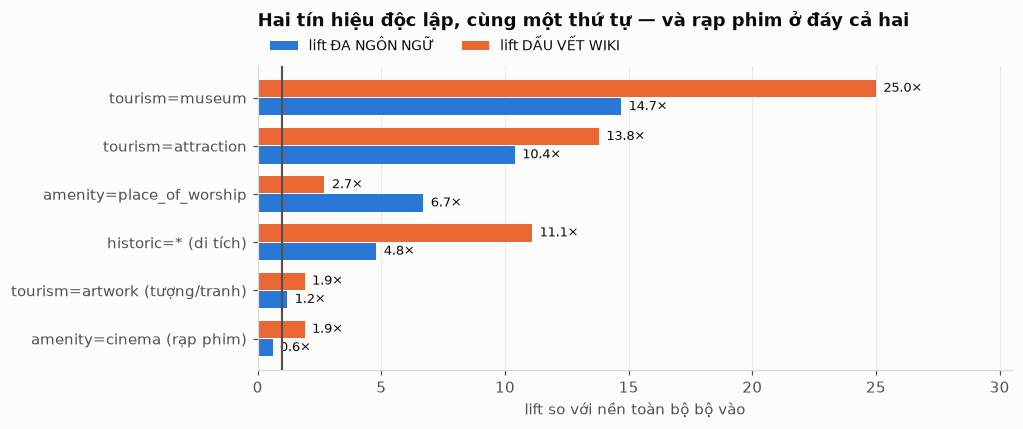

In [8]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


# THANG dựng CHỈ bằng dấu vết TRI THỨC NGOÀI (wiki + heritage) — cố ý không dùng đa ngôn ngữ.
tq["suc_hut_tri_thuc"] = np.select(
    [tq["co_heritage"], tq["co_wiki"]], ["DI_SAN_XEP_HANG", "CO_DAU_VET_WIKI"], default="KHONG_CO"
)

print(
    "── KIỂM CHÉO: thang dựng bằng wiki/di sản, đo bằng ĐA NGÔN NGỮ (tín hiệu không dùng để dựng) ──"
)
kc = tq.groupby("suc_hut_tri_thuc").agg(
    n=("n_lang", "size"),
    da_ngu=("n_lang", lambda s: (s >= 2).mean()),
    ngon_ngu_tv=("n_lang", "median"),
)
print(kc.assign(da_ngu=lambda d: (d.da_ngu * 100).round(1)).to_string())
_p_co = kc.loc[kc.index != "KHONG_CO", "da_ngu"] if "KHONG_CO" in kc.index else None
print(
    "→ thang KHÔNG tự nói về chính nó: nhóm có dấu vết tri thức có tỷ lệ đa ngôn ngữ cao hơn"
    " hẳn nhóm không có, dù đa ngôn ngữ chưa hề tham gia dựng thang."
)

# THANG CHỐT — hợp cả ba dấu vết, xếp từ mạnh xuống yếu.
tq["suc_hut"] = np.select(
    [
        tq["co_heritage"] | (tq["n_lang"] >= 4),
        tq["co_wiki"] | (tq["n_lang"] >= 2),
        tq["tourism"].isin(["attraction", "museum", "viewpoint", "zoo", "aquarium", "theme_park"]),
    ],
    ["QUOC_GIA_QUOC_TE", "VUNG", "DIA_PHUONG_CO_KHAI"],
    default="DIA_PHUONG",
)
tq["suc_hut_nguon"] = np.select(
    [tq["co_heritage"], tq["co_wiki"], tq["n_lang"] >= 2, tq["tourism"].notna()],
    ["heritage", "wiki", "da_ngon_ngu", "tu_khai_tag"],
    default="khong_co",
)
print()
print(tq["suc_hut"].value_counts().to_string())
print()
print(pd.crosstab(tq["suc_hut"], tq["suc_hut_nguon"]).to_string())

fig, ax = plt.subplots(figsize=(9.4, 4.0))
b = bang.loc[[i for i in bang.index if i != "NỀN — toàn bộ bộ vào"]].sort_values("lift ngôn ngữ")
x = np.arange(len(b))
ax.barh(x - 0.19, b["lift ngôn ngữ"], height=0.36, color=BLUE, label="lift ĐA NGÔN NGỮ")
ax.barh(x + 0.19, b["lift wiki"], height=0.36, color=ORANGE, label="lift DẤU VẾT WIKI")
ax.axvline(1.0, color=MUTED, linewidth=1.4, zorder=5)
ax.annotate("1× = ngang mức nền", (1.0, -0.75), ha="left", va="top", fontsize=8.5, color=MUTED)
for i, (l1, l2) in enumerate(zip(b["lift ngôn ngữ"], b["lift wiki"])):
    ax.text(l1 + 0.3, i - 0.19, f"{l1:.1f}×", va="center", fontsize=8.5, color=INK)
    ax.text(l2 + 0.3, i + 0.19, f"{l2:.1f}×", va="center", fontsize=8.5, color=INK)
ax.set_yticks(x)
ax.set_yticklabels(b.index)
ax.set_xlim(0, max(b["lift wiki"].max(), b["lift ngôn ngữ"].max()) * 1.22)
ax.grid(axis="y", visible=False)
ax.set_xlabel("lift so với nền toàn bộ bộ vào")
ax.set_title("Hai tín hiệu độc lập, cùng một thứ tự — và rạp phim ở đáy cả hai", pad=26, loc="left")
ax.legend(ncol=2, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### REVIEW — thang sức hút

**Soi gì:** ba dấu vết trên 7 nhóm tham chiếu, cộng phép kiểm chéo (dựng thang bằng
wiki/di sản, đo bằng đa ngôn ngữ).

**Tìm được:**
- Ba dấu vết **xếp cùng một thứ tự** dù đến từ ba nguồn khác nhau: bảo tàng > điểm tham
  quan > di tích > nơi thờ tự > tượng công cộng > rạp phim.
- **Rạp phim là ca đối chứng tốt nhất**: lift ngôn ngữ 0,6× và wiki 2,0× — dưới hoặc sát
  nền. Nó đúng là điểm đến, nhưng của người ĐỊA PHƯƠNG. Thang xếp nó đúng chỗ mà không cần
  ai nói trước cho nó biết.
- **Phép kiểm chéo không phẳng**, nên thang không phải tự nói về chính nó.

**Quyết định:** cột `suc_hut` (4 bậc) + `suc_hut_nguon` (bằng chứng đến từ đâu). Đây là
thang **sức hút**, KHÔNG phải thang quy mô — dùng nhầm sẽ sai: một ngôi chùa bậc
`QUOC_GIA_QUOC_TE` có thể chỉ rộng 300 m².

**Giới hạn phải ghi nợ:** cả ba dấu vết đều là dấu vết của NGƯỜI MAP, không phải của KHÁCH.
Nơi nào cộng đồng OSM hoạt động mạnh (Hà Nội, Hội An) thì mọi dấu vết đều dày hơn. Chưa
hiệu chỉnh theo tỉnh.

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: mỗi luật một cell

In [9]:
candidates = tq.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []


# HỌ TAG CỦA LỚP KHÁC — MỘT nguồn sự thật, dùng ở hai chỗ: LUẬT 4 (xoá) và nhánh wiki
# của `co_bang_chung_tham_quan` (tha). Trước đây hai chỗ này có hai danh sách khác nhau và
# đó chính là kẽ hở: luật xoá biết `amenity=hospital` là lớp khác, nhưng nhánh tha thì
# không, nên "Bệnh viện Bạch Mai" bị THA vì có `wikidata` — rồi bị trừ khỏi bộ CÒN LẠI nên
# lớp y tế chạy sau không còn nhìn thấy nó nữa.
AMENITY_LOP_KHAC = [
    "restaurant", "cafe", "fast_food", "bar", "pub", "parking", "fuel", "bank", "atm",
    "pharmacy", "school", "kindergarten", "university", "college", "hospital", "clinic",
    "doctors", "dentist", "marketplace", "bus_station", "toilets", "shelter", "police",
    "fire_station", "post_office", "townhall", "courthouse", "prison",
    # ── THIẾT BỊ ĐẶT NHỜ ĐỊA ĐIỂM (thẩm định 2026-08-09) ──
    # Vật thể là THIẾT BỊ, cái tên là ĐỊA ĐIỂM CHỦ: "TNGo - Bảo tàng Chiến thắng B52",
    # "TNGo - Học viện Ngoại giao", "TNGo - Vincom Phạm Ngọc Thạch". Chúng lọt vào lớp
    # qua nhánh TÊN, và vì là node trần không mang `highway`/`public_transport` nên luật
    # hạ tầng đường KHÔNG bắt được. Đây là bẫy "tên là mốc tham chiếu" ở dạng thuần nhất.
    # Đo 2026-08-09: 12 dòng rải ở 4 lớp. Ở quy mô toàn quốc xe đạp công cộng đang mở
    # rộng nhanh, nên đây là danh sách chặn theo TAG (không theo tên) để khỏi phải đuổi
    # theo từng thương hiệu.
    "bicycle_rental",
    "vending_machine",
    "parcel_locker",
]
# ⚠ `events_venue` ĐÃ THỬ VÀ BỊ GỠ. Thêm nó xoá đúng 1 dòng đáng xoá ("Cung Xuân") nhưng
# kéo theo 5 dòng đúng: "Cung Văn hóa Thể thao Thanh niên Hà Nội", "Trung tâm Văn hóa Xứ
# Đông", "Trung tâm văn hóa nghệ thuật tỉnh Hải Dương" ×2 và "Tháp nước Hàng Đậu". Ở VN
# nhà văn hoá / cung văn hoá hay được map bằng tag này — đó là THIẾT CHẾ VĂN HOÁ, tức
# nguyên liệu của chính lớp này. Bài học: danh sách tag "lớp khác" chỉ được nhận tag mà
# TOÀN BỘ họ của nó thuộc lớp khác, không nhận tag chỉ ĐA SỐ thuộc lớp khác.
LEISURE_LOP_KHAC = ["pitch", "swimming_pool", "fitness_centre", "playground"]
# ĐƠN VỊ CƯ TRÚ / HÀNH CHÍNH. Không thuộc lớp nào — đây là NHÃN ĐỊA LÝ, không phải cơ sở.
# Phải nằm ở đây chứ không chỉ ở LUẬT 4B, vì luật đó chạy kèm van tha: "Hà Nội", "Hội An",
# "Ba Chẽ", "Cờ Đỏ" có `wikidata` nên nhánh wiki gọi chúng là bằng chứng tham quan và tha
# ngược lại đúng cái luật sinh ra để xoá chúng — 182 dòng được tha như vậy. Đo được: chúng
# chiếm phần lớn sai số còn lại của lớp, tất cả đội lốt `hang_tq = KHAC`.
# `island`/`islet`/`archipelago` KHÔNG có ở đây: đảo là điểm đến thật (Cát Bà, Ngọc Vừng),
# LUẬT 4B vẫn xử chúng riêng và vẫn cho tha.
PLACE_CU_TRU = [
    "city", "town", "village", "hamlet", "suburb", "quarter", "neighbourhood", "borough",
    "district", "province", "region", "county", "municipality", "state", "city_block",
]


def mang_tag_lop_khac(df):
    """Dòng TỰ KHAI mình thuộc họ của một lớp khác trong dây chuyền."""
    return (
        df["amenity"].isin(AMENITY_LOP_KHAC)
        | df["shop"].notna()
        | df["office"].notna()
        | df["healthcare"].notna()
        | df["leisure"].isin(LEISURE_LOP_KHAC)
        | df["highway"].notna()
        | df["public_transport"].notna()
        | df["railway"].notna()
        | df["aeroway"].notna()
        # NHÀ GA DẠNG POLYGON. Bài học "127 ga có wikidata" được vá bằng 4 tag hạ tầng ở
        # trên — nhưng khối nhà ga (polygon) không mang `railway=*`, nó mang
        # `building=transportation`. 8 ga tuyến Nhổn–ga Hà Nội vì thế vẫn lọt vào lớp qua
        # `wikidata`, một trong số đó còn được dán nhãn CO_SO_THO_TU ("Ga Chùa Hà").
        # Cùng một bài học, lần thứ ba, ở một khoá tag khác.
        | df["building"].isin(["transportation", "train_station"])
        | df["place"].isin(PLACE_CU_TRU)
    )


def co_bang_chung_tham_quan(df):
    """Bằng chứng ĐIỂM THAM QUAN — tự khai bằng tag, hoặc được ghi nhận ngoài OSM."""
    return (
        df["tourism"].isin(
            ["attraction", "museum", "viewpoint", "zoo", "aquarium", "theme_park", "gallery"]
        )
        | df["historic"].notna()
        | df["religion_that"]
        | df["amenity"].eq("place_of_worship")
    ) | (
        # `co_wiki` / `co_heritage` là bằng chứng BỔ TRỢ, không ĐỊNH DANH — đã trả giá HAI
        # lần. Lần 1: 127 GA ĐƯỜNG SẮT ("Ga Bảy Hiền", "Yên Viên") có `wikidata` nên bị
        # tính là điểm tham quan. Lần 2 (nặng hơn, thẩm định 2026-08-09 bắt được): bản vá
        # lần 1 chỉ chặn 4 tag hạ tầng, nên 34 BỆNH VIỆN TRUNG ƯƠNG (Bạch Mai, Nhi TƯ,
        # 108, Quân y 175), 155 trường/ĐH và 120 `office` vẫn lọt — và vì dây chuyền TRỪ
        # `final` khỏi bộ còn lại, lớp y tế chạy sau mất trắng cả 34 (0/34 có mặt trong
        # `poi_benhvien_final`). Tiêu chí lọc nhầm chính là "nổi tiếng đến mức có
        # Wikipedia", nên thứ bị nuốt đúng là những cơ sở đầu ngành lớn nhất.
        #
        # Quy tắc chốt (notebook tự viết ở Bàn giao, nay áp dụng ĐỦ chứ không nửa vời):
        # dấu vết ngoài OSM chỉ được tính khi dòng KHÔNG tự khai mình thuộc một họ khác.
        # Chùa nằm trong khuôn viên bệnh viện vẫn giữ được — nó đi qua nhánh TAG ở trên.
        (df["co_wiki"] | df["co_heritage"]) & ~mang_tag_lop_khac(df)
    )


def drop_rule(cond, rule, n=6, tha_diem_tham_quan=False):
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_diem_tham_quan:
        tha = m & co_bang_chung_tham_quan(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(
                f"  ⊙ {tha.sum()} dòng có bằng chứng THAM QUAN → GIỮ, cờ mixed_use:",
                remaining.loc[tha, "name"].dropna().head(5).tolist(),
            )
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_bang_chung_tham_quan(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng có bằng chứng tham quan:",
            conflict["name"].dropna().head(8).tolist(),
        )
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 11,434 dòng


In [10]:
# LUẬT 1 — hạ tầng đường. Luật số 1 của năm lớp liên tiếp; ở đây nó bắt các trạm buýt lấy
# chùa / bảo tàng làm mốc.
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print(
    "dòng có bằng chứng tham quan mà dính luật này:",
    int((INFRA & co_bang_chung_tham_quan(remaining)).sum()),
)
print()
drop_rule(INFRA, "HA_TANG_DUONG")

dòng có bằng chứng tham quan mà dính luật này: 4

HA_TANG_DUONG: xoá 1,466  →  còn lại 9,968
  mẫu : ['Phú Thụy', 'Yên Viên', 'Gia Lâm', 'Bến Đình Bình Đông', '216 Nguyễn Trãi - Nhà Văn hóa tổ dân phố số 8 & 9 Phường Trung Văn', 'Long Biên']
  ⚠ 4 dòng có bằng chứng tham quan: ['Lăng Lê Văn Duyệt', 'Chùa Bửu Long', '0 km', 'Cổng Chùa Bà Mụ']


In [11]:
# LUẬT 2 — NHÀ THỜ HỌ / TỪ ĐƯỜNG / LĂNG MỘ GIA ĐÌNH. Bẫy tiếng Việt riêng của lớp này:
# "nhà thờ" trong "nhà thờ họ Nguyễn" KHÔNG phải nhà thờ Công giáo mà là nơi thờ tổ tiên
# một dòng họ — công trình TƯ NHÂN, không mở cho khách. Cùng logic với lăng mộ gia đình.
#
# Tha dòng có bằng chứng tham quan: lăng vua, nhà thờ họ được xếp hạng di tích là có thật.
TU_DUONG = (
    remaining["name_norm"].str.contains(
        r"nha tho (?:to|ho|dong|chi)|\btu duong\b|nha tho gia toc|mo gia dinh|mo to|khu mo",
        na=False,
    )
    | remaining["historic"].isin(["tomb"]) & remaining["name"].isna()
)
print()
drop_rule(TU_DUONG, "TU_DUONG_MO_GIA_DINH", tha_diem_tham_quan=True)


  ⊙ 58 dòng có bằng chứng THAM QUAN → GIỮ, cờ mixed_use: ['Nhà Thờ Hòa Bình', 'Nhà thờ họ Hoa Văn', 'Từ đường tộc Lương Phú Trà', 'Tran Family Chapel', 'Nhà thờ Hoà Cường']
TU_DUONG_MO_GIA_DINH: xoá 3  →  còn lại 9,965
  mẫu : ['nhà thờ tổ họ lê', 'Nhà thờ tổ Nguyễn Sinh Hùng', 'Nhà Thờ Tộc Trần Văn']


In [12]:
# LUẬT 3 — BIỂN CHỈ DẪN, không phải điểm đến. `tourism=information` là bảng thông tin /
# bản đồ du lịch đặt bên đường — nó TRỎ TỚI điểm tham quan, không phải điểm tham quan.
# Đúng nguyên tắc "mốc tham chiếu" của lớp nhà ở, ở dạng tag thay vì dạng tên.
BIEN_CHI_DAN = remaining["tourism"].eq("information") | remaining["man_made"].isin(
    ["surveillance", "flagpole"]
)
print(
    "phân bố `information=*`:",
    remaining.loc[BIEN_CHI_DAN, "tags_dict"]
    .map(lambda t: t.get("information"))
    .value_counts()
    .head(6)
    .to_dict(),
)
print()
drop_rule(BIEN_CHI_DAN, "BIEN_CHI_DAN", tha_diem_tham_quan=True)

phân bố `information=*`: {'board': 63, 'map': 28, 'office': 20, 'guidepost': 10, 'terminal': 2, 'visitor_centre': 1}

  ⊙ 1 dòng có bằng chứng THAM QUAN → GIỮ, cờ mixed_use: ['Maitrism']


BIEN_CHI_DAN: xoá 200  →  còn lại 9,765
  mẫu : ['đường vào đền Cao', 'Thai Express', 'Du Lịch Hùng Vỹ', 'Canthotourist', 'Internet Giọt Nắng', 'Cửa hàng giấy dán tường hoa Việt Hàn']


In [13]:
# LUẬT 4 — họ tag thuộc LỚP KHÁC. Quán ăn trong khu di tích, cửa hàng lưu niệm, bãi đỗ.
NGOAI_LOP = mang_tag_lop_khac(remaining)
print()
drop_rule(NGOAI_LOP, "TAG_LOP_KHAC", tha_diem_tham_quan=True)


  ⊙ 32 dòng có bằng chứng THAM QUAN → GIỮ, cờ mixed_use: ['Cửa Hàng Xăng Dầu Petrolimex', 'Đinh Thường-90 Lê Lương', 'Cà Phê Điêu Thuyền', 'Disco Travel - Du lịch Quốc Tế Khám Phá', 'Công Ty CJ FRESHWAY VIỆT NAM']
TAG_LOP_KHAC: xoá 1,144  →  còn lại 8,621
  mẫu : ['Hà Nội', 'Hội An', 'Hồng Gai', 'Thành phố Hồ Chí Minh', 'Vị Thanh', 'Đà Nẵng']


In [14]:
# LUẬT 4B — NODE ĐỊA DANH HÀNH CHÍNH. Nhánh C (dấu vết wiki) kéo vào 500+ node `place=city|
# town|suburb`: "Hà Nội", "Hội An", "Đà Nẵng" đều có `wikidata` — đúng là nổi tiếng, nhưng
# một THÀNH PHỐ không phải một điểm tham quan đếm được.
#
# Đây là mặt trái đã lường trước của việc dùng "dấu vết tri thức ngoài OSM" làm nhánh tuyển:
# wiki đo ĐỘ NỔI TIẾNG, và độ nổi tiếng không phân biệt cái gì là một cơ sở. Lớp nhà ở gặp
# đúng ca này ở LUẬT 10 của nó (`place=island|city|town`), và lời giải giống hệt.
PLACE_DIA_LY = remaining["place"].isin(
    ["city", "town", "village", "hamlet", "suburb", "quarter", "neighbourhood", "borough",
     "district", "province", "region", "county", "municipality", "locality", "island",
     "islet", "archipelago", "sea", "ocean", "state", "city_block", "square"]
)
print("phân bố place:", remaining.loc[PLACE_DIA_LY, "place"].value_counts().head(8).to_dict())
print()
drop_rule(PLACE_DIA_LY, "PLACE_DIA_LY", tha_diem_tham_quan=True)

phân bố place: {'islet': 16, 'island': 11, 'square': 5, 'village': 2, 'archipelago': 2, 'locality': 1}

  ⊙ 19 dòng có bằng chứng THAM QUAN → GIỮ, cờ mixed_use: ['Cù Lao Bến Đình', 'Cẩm Kim', 'Hòn Dấu', 'Hòn Bà', 'Hòn Gà chọi']
PLACE_DIA_LY: xoá 18  →  còn lại 8,603
  mẫu : ['甲水岛', 'Bãi tắm New Wave', 'Đảo Rùa', 'Hòn Chàng Đông 1', '独墩岛', 'Hòn Chàng Đông']


In [15]:
# LUẬT 5 — tên nói thẳng đây là loại khác. Danh sách HẸP, neo biên chặt.
# Bài học lặp lại lần thứ năm: "truong " trần là tên riêng ("Trường Sơn"), phải đi kèm cấp học.
TEN_LOAI_KHAC = remaining["name_norm"].str.contains(
    r"benh vien|phong kham|\bubnd\b|uy ban nhan dan|\bcong an\b|toa an|kho bac|buu dien"
    r"|\bngan hang\b|nha may|xi nghiep|\bkcn\b|khach san|nha nghi|\bcay xang\b|tram xang"
    r"|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc|cao dang)|\bcho \b"
    r"|sieu thi|trung tam thuong mai|\bbai do xe\b|\bnha xe\b|ben xe|\bkhu cong nghiep\b",
    na=False,
) & ~co_bang_chung_tham_quan(remaining)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


TEN_LOAI_KHAC: xoá 27  →  còn lại 8,576
  mẫu : ['Khu Công Nghiệp Đình Vũ', 'Thư viện Trường Đại học Nông Lâm', 'bến xe Đà Nẵng', 'khách sạn Xanh - đường Hoàng văn Thái', '• KCN- nam tân uyên mởv rộng', 'Cong an My An']


In [16]:
# LUẬT 6 — MỐC THAM CHIẾU.
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 1  →  còn lại 8,575
  mẫu : ['Cổng Khu du lịch Chí Linh']
  ⚠ 1 dòng có bằng chứng tham quan: ['Cổng Khu du lịch Chí Linh']


In [17]:
# CỔNG HẬU KIỂM.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

LUAT_CO_Y = {"TU_DUONG_MO_GIA_DINH", "BIEN_CHI_DAN", "TAG_LOP_KHAC"}
conflict = removed[co_bang_chung_tham_quan(removed)]
print(f"POI có bằng chứng THAM QUAN nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(
        cf_ngoai_y[["name", "tourism", "historic", "amenity", "drop_reason"]].head(25).to_string()
    )
assert len(cf_ngoai_y) <= 30, f"{len(cf_ngoai_y)} dòng tham quan bị luật NGOÀI Ý xoá"

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== nhóm rủi ro nhất: tên có 'chùa/bảo tàng/di tích' mà vẫn bị xoá ==")
risky = removed[
    removed["name_dau"].astype(object).str.contains(r"\bchùa\b", na=False)
    | removed["name_norm"].str.contains(r"bao tang|di tich", na=False)
]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI có bằng chứng THAM QUAN nhưng bị xoá: 5 — phân theo luật:
drop_reason
HA_TANG_DUONG     4
MOC_THAM_CHIEU    1

── do LUẬT NGOÀI Ý (phải nhỏ): 5 ──
                             name     tourism historic           amenity     drop_reason
7829            Lăng Lê Văn Duyệt         NaN    ruins               NaN   HA_TANG_DUONG
8675                Chùa Bửu Long         NaN      NaN  place_of_worship   HA_TANG_DUONG
100493                       0 km  attraction      NaN               NaN   HA_TANG_DUONG
142944            Cổng Chùa Bà Mụ         NaN      NaN  place_of_worship   HA_TANG_DUONG
3092    Cổng Khu du lịch Chí Linh  attraction      NaN               NaN  MOC_THAM_CHIEU

== tổng hợp theo luật ==
drop_reason
HA_TANG_DUONG           1466
TAG_LOP_KHAC            1144
BIEN_CHI_DAN             200
TEN_LOAI_KHAC             27
PLACE_DIA_LY              18
TU_DUONG_MO_GIA_DINH       3
MOC_THAM_CHIEU             1

== nhóm rủi ro nhất: tên có 'chùa/bảo tàng/di tích' mà vẫn bị xoá ==
432 

In [18]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
print("tỷ lệ sống sót theo nhánh tuyển:")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:26s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:26s} —")

giữ : 8,575 → poi_thamquan_7tinh_b3.parquet
xoá : 2,859 → poi_thamquan_7tinh_b3_bi_xoa.parquet

tỷ lệ sống sót theo nhánh tuyển:
  A tag du lịch/di tích      7,756/7,980  = 97%
  B tên                      4,622/6,286  = 74%
  B2 nghĩa trang liệt sĩ (tag+tên)    86/86     = 100%


  C dấu vết wiki/di sản        342/949    = 36%
  D tên ≥4 ngôn ngữ            221/806    = 27%
  E vòng đời                 —


## Bước 4 — ĐO, không quyết

hang_tq
CO_SO_THO_TU           5194
DIEM_THAM_QUAN_KHAC     786
DI_TICH                 746
THIET_CHE_VAN_HOA       524
TAC_PHAM_CONG_CONG      448
KHAC                    210
RAP_PHIM_NHA_HAT        199
BAO_TANG                197
NGHIA_TRANG             130
TUONG_NIEM               96
CANH_QUAN_TU_NHIEN       45

suc_hut              DIA_PHUONG  DIA_PHUONG_CO_KHAI  QUOC_GIA_QUOC_TE  VUNG
hang_tq                                                                    
BAO_TANG                     26                 109                23    39
CANH_QUAN_TU_NHIEN           21                  18                 0     6
CO_SO_THO_TU               4618                  14               176   386
DIEM_THAM_QUAN_KHAC          56                 660                12    58
DI_TICH                     640                  17                29    60
KHAC                         68                   0                29   113
NGHIA_TRANG                 127                   0                 0     3

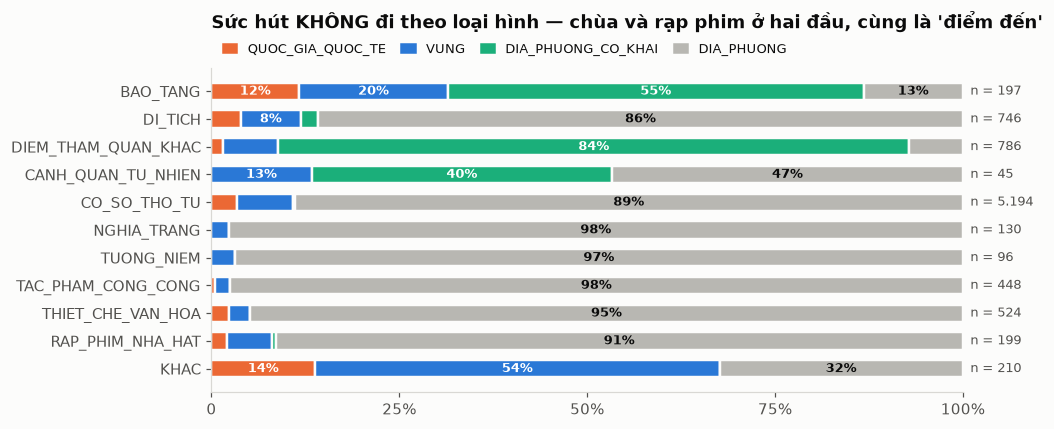

In [19]:
# [DATA] sinh cột: hang_tq, loai_tho_tu
# `nn_c` = bỏ dấu (cho CỤM đa âm) · `nd_c` = còn dấu (cho token ĐƠN ÂM). Cùng ranh giới
# như bước 1 — nếu tách tầng ở bước tuyển mà bước gán nhãn vẫn dùng bản bỏ dấu thì
# "Sữa Chua Trân Châu Hạ Long" vào lớp qua cửa khác rồi vẫn bị dán nhãn CO_SO_THO_TU.
nn_c = clean["name_norm"]
nd_c = clean["name_dau"].astype(object)
hang = pd.Series("KHAC", index=clean.index)
for cond, val in [
    (
        clean["tourism"].eq("museum")
        | clean["building"].eq("museum")
        | nn_c.str.contains(r"bao tang|nha trung bay|nha truyen thong", na=False),
        "BAO_TANG",
    ),
    (
        clean["amenity"].isin(["cinema", "theatre", "arts_centre"])
        | nn_c.str.contains(
            r"\brap (?:phim|chieu|hat)?\b|nha hat|san khau kich|\bcgv\b|cinema", na=False
        ),
        "RAP_PHIM_NHA_HAT",
    ),
    (
        # NGHĨA TRANG đứng TRƯỚC cơ sở thờ tự. Nghĩa trang giáo xứ mang `religion=christian`
        # nên trước đây rơi hết vào CO_SO_THO_TU — nó là nơi chôn cất, không phải nơi thờ
        # tự, và trộn hai thứ làm hỏng mọi thống kê "bao nhiêu cơ sở tôn giáo". Nghĩa trang
        # LIỆT SĨ được chừa ra để rơi xuống TUONG_NIEM như quyết định cũ (đảo được).
        (
            clean["amenity"].eq("grave_yard")
            | clean["landuse"].eq("cemetery")
            | nd_c.str.contains(r"nghĩa trang|nghĩa địa|đất thánh", na=False)
        )
        & ~nd_c.str.contains(r"liệt sĩ|liệt sỹ", na=False),
        "NGHIA_TRANG",
    ),
    (
        clean["amenity"].eq("place_of_worship")
        | clean["religion_that"]
        | clean["building"].isin(
            ["temple", "church", "mosque", "cathedral", "chapel", "shrine", "pagoda"]
        )
        | nn_c.str.contains(r"nha tho|thanh that|tinh xa|\btu vien\b", na=False)
        # Cùng quy tắc VỊ TRÍ như bước tuyển: âm tiết loại hình phải ĐỨNG ĐẦU cụm. Không
        # có nó thì "Ga Thượng Đình" / "Công ty Điện lực Ba Đình" vào lớp qua cửa khác rồi
        # vẫn bị dán nhãn cơ sở thờ tự.
        | nd_c.str.contains(r"(?:\bchùa\b|\bđình\b|\bđền\b|\bmi[ếễ]u\b)(?=\s+\w)", na=False),
        "CO_SO_THO_TU",
    ),
    (
        clean["historic"].notna()
        | clean["co_heritage"]
        | nn_c.str.contains(r"di tich|thanh co|hoang thanh|van mieu|cot co", na=False),
        "DI_TICH",
    ),
    (
        clean["historic"].isin(["memorial", "monument"])
        # `s[iy]` + cặp tag-tên: đồng bộ với nhánh tuyển B2 — không có dòng dưới thì
        # "Nghĩ Trang Liệt Sĩ Tình Tiền Giang" (typo) vào lớp xong lại rơi nhãn KHAC.
        | nn_c.str.contains(
            r"dai tuong niem|dai liet s[iy]|tuong dai|nha bia"
            r"|nghia trang liet s[iy]|den liet s[iy]",
            na=False,
        )
        | (
            (clean["landuse"].eq("cemetery") | clean["amenity"].eq("grave_yard"))
            & nn_c.str.contains(r"liet s[iy]", na=False)
        ),
        "TUONG_NIEM",
    ),
    (clean["tourism"].eq("artwork"), "TAC_PHAM_CONG_CONG"),
    (
        clean["natural"].isin(["beach", "cave_entrance", "peak", "hot_spring"])
        | nn_c.str.contains(
            r"bai bien|\bbeach\b|hang dong|thac \b|suoi khoang|thang canh|danh lam", na=False
        ),
        "CANH_QUAN_TU_NHIEN",
    ),
    (
        clean["tourism"].isin(
            ["attraction", "viewpoint", "zoo", "aquarium", "theme_park", "gallery"]
        )
        | clean["man_made"].eq("lighthouse")
        | nn_c.str.contains(r"diem tham quan|khu du lich|\bkdl\b", na=False),
        "DIEM_THAM_QUAN_KHAC",
    ),
    (
        clean["amenity"].isin(["library"])
        | nn_c.str.contains(
            r"thu vien|trung tam van hoa|nha van hoa|cung van hoa|nha thieu nhi|cung thieu nhi",
            na=False,
        ),
        "THIET_CHE_VAN_HOA",
    ),
]:
    hang[cond & hang.eq("KHAC")] = val
clean["hang_tq"] = hang

lt = pd.Series(None, index=clean.index, dtype=object)
for ten, rx in LOAI_THO_TU:
    lt[clean["hang_tq"].eq("CO_SO_THO_TU") & nd_c.str.contains(rx, na=False) & lt.isna()] = ten
clean["loai_tho_tu"] = lt

print(clean["hang_tq"].value_counts().to_string())
print()
print(pd.crosstab(clean["hang_tq"], clean["suc_hut"]).to_string())
print("\nloại thờ tự:", clean["loai_tho_tu"].value_counts(dropna=False).to_dict())

fig, ax = plt.subplots(figsize=(9.6, 4.0))
SH = ["QUOC_GIA_QUOC_TE", "VUNG", "DIA_PHUONG_CO_KHAI", "DIA_PHUONG"]
SH_C = {"QUOC_GIA_QUOC_TE": ORANGE, "VUNG": BLUE, "DIA_PHUONG_CO_KHAI": GREEN, "DIA_PHUONG": GRAY}
HG = [
    h
    for h in [
        "BAO_TANG",
        "DI_TICH",
        "DIEM_THAM_QUAN_KHAC",
        "CANH_QUAN_TU_NHIEN",
        "CO_SO_THO_TU",
        "NGHIA_TRANG",
        "TUONG_NIEM",
        "TAC_PHAM_CONG_CONG",
        "THIET_CHE_VAN_HOA",
        "RAP_PHIM_NHA_HAT",
        "KHAC",
    ]
    if h in set(clean["hang_tq"])
]
tab = pd.crosstab(clean["hang_tq"], clean["suc_hut"]).reindex(index=HG, columns=SH).fillna(0)
share = tab.div(tab.sum(axis=1), axis=0)
left = np.zeros(len(tab))
for s in SH:
    v = share[s].values
    ax.barh(tab.index, v, left=left, color=SH_C[s], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, p in enumerate(v):
        if p > 0.08:
            ax.text(
                left[y] + p / 2,
                y,
                f"{p:.0%}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if s != "DIA_PHUONG" else INK,
                fontweight="bold",
            )
    left += v
for y, ten in enumerate(tab.index):
    ax.text(1.01, y, f"n = {fmt(tab.loc[ten].sum())}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
ax.grid(visible=False)
ax.set_title(
    "Sức hút KHÔNG đi theo loại hình — chùa và rạp phim ở hai đầu, cùng là 'điểm đến'",
    pad=26,
    loc="left",
)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=SH_C[s]) for s in SH],
    labels=SH,
    ncol=4,
    loc="lower left",
    bbox_to_anchor=(0, 1.0),
    frameon=False,
    fontsize=8.5,
    handlelength=1.1,
    columnspacing=1.2,
)
fig.tight_layout()
plt.show()

In [20]:
# [DATA] sinh cột: container_uid, fragment_group
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values
vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]
container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    q = TREE.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS[k]) for k in q]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid
clean["container_uid"] = clean["uid"].map(container)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(
    f"dòng nằm trong polygon tham quan khác: {n_ct:,} → đếm CƠ SỞ: {n_row - n_ct:,} thay vì {n_row:,}"
)
print(
    f"nhóm trùng tên cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)
print("\n5 polygon chứa nhiều POI con nhất:")
for u, k in clean["container_uid"].value_counts().head(5).items():
    r = clean.loc[clean["uid"].eq(u)].iloc[0]
    print(f"  {k:3d} POI con — {r['name'] or '(vô danh)'} | {r['hang_tq']} | {r['suc_hut']}")

dòng nằm trong polygon tham quan khác: 1,978 → đếm CƠ SỞ: 6,597 thay vì 8,575
nhóm trùng tên cùng ô H3: 127 nhóm, 269 dòng

5 polygon chứa nhiều POI con nhất:
   74 POI con — Đặc khu Côn Đảo | KHAC | VUNG
   52 POI con — Thánh địa Mỹ Sơn | CO_SO_THO_TU | QUOC_GIA_QUOC_TE
   50 POI con — Chùa Linh Ứng | CO_SO_THO_TU | DIA_PHUONG
   31 POI con — Ngũ Hành Sơn | DIEM_THAM_QUAN_KHAC | VUNG
   20 POI con — Cù Lao Phố | KHAC | VUNG


## Bước 5 — FINAL và bộ CÒN LẠI

In [21]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\nhang_tq:", final["hang_tq"].value_counts().to_dict())
print("suc_hut:", final["suc_hut"].value_counts().to_dict())
print(f"số CƠ SỞ (lọc container_uid): {final['container_uid'].isna().sum():,}")
print()
print(
    final.groupby("hang_tq")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 8,575 dòng, 70 cột → poi_thamquan_7tinh_final.parquet

hang_tq: {'CO_SO_THO_TU': 5194, 'DIEM_THAM_QUAN_KHAC': 786, 'DI_TICH': 746, 'THIET_CHE_VAN_HOA': 524, 'TAC_PHAM_CONG_CONG': 448, 'KHAC': 210, 'RAP_PHIM_NHA_HAT': 199, 'BAO_TANG': 197, 'NGHIA_TRANG': 130, 'TUONG_NIEM': 96, 'CANH_QUAN_TU_NHIEN': 45}
suc_hut: {'DIA_PHUONG': 6765, 'DIA_PHUONG_CO_KHAI': 819, 'VUNG': 704, 'QUOC_GIA_QUOC_TE': 287}
số CƠ SỞ (lọc container_uid): 6,597

hang_tq                BAO_TANG  CANH_QUAN_TU_NHIEN  CO_SO_THO_TU  DIEM_THAM_QUAN_KHAC  DI_TICH  KHAC  NGHIA_TRANG  RAP_PHIM_NHA_HAT  TAC_PHAM_CONG_CONG  THIET_CHE_VAN_HOA  TUONG_NIEM
province_name                                                                                                                                                                          
Thành phố Cần Thơ             6                   0           389                   34       24     2            5                 9                  10                 20          12
Thành 

In [22]:
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP}.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)
print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")
_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)
for ten_lop in ["chungcu", "luutru", "thuongmai", "giaitri"]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp TRƯỜNG HỌC trong bộ còn lại:")
_am = _td.map(lambda t: t.get("amenity"))
print(
    "  amenity:",
    _am[_am.isin(["school", "kindergarten", "college", "university", "language_school"])]
    .value_counts()
    .to_dict(),
)
print(
    "  building=school/university:",
    _td.map(lambda t: t.get("building"))
    .isin(["school", "university", "college", "kindergarten"])
    .sum(),
)

bộ vào    : 171,244
đã bóc ra : 8,575
CÒN LẠI   : 162,669  → poi_extended_7tinh_con_lai_sau_thamquan.parquet


✓ 2,859 dòng bị 7 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru
✓ không đếm đôi với lớp thuongmai
✓ không đếm đôi với lớp giaitri



nguyên liệu lớp TRƯỜNG HỌC trong bộ còn lại:
  amenity: {'school': 4615, 'kindergarten': 1255, 'university': 357, 'college': 342, 'language_school': 75}
  building=school/university: 4885


---

### CHỐT LỚP THAM QUAN

Đầu ra: `data/qa/eda/poi_thamquan_7tinh_final.parquet` (+ `poi_extended_7tinh_con_lai_sau_thamquan.parquet` cho lớp sau) — **8.559 dòng / 70 cột**.
Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

| `hang_tq` | Số dòng | Ghi chú |
| --- | ---: | --- |
| `CO_SO_THO_TU` | 5.193 | nhóm áp đảo, **rất không đồng nhất** — đình trung vị 281 m² vs chùa 2.716 m², chênh 10 lần. Phải đọc kèm `loai_tho_tu` |
| `DIEM_THAM_QUAN_KHAC` | 786 | gồm cả 31 hải đăng (`man_made=lighthouse`) |
| `DI_TICH` | 746 | |
| `THIET_CHE_VAN_HOA` | 524 | nhà văn hoá · thư viện · nhà/cung thiếu nhi |
| `TAC_PHAM_CONG_CONG` | 448 | |
| `KHAC` | 210 | **nhóm bẩn nhất — xem lỗi #1** |
| `RAP_PHIM_NHA_HAT` | 199 | bản chất cầu khác hẳn phần còn lại — xem lỗi #4 |
| `BAO_TANG` | 197 | |
| `NGHIA_TRANG` | 130 | nghĩa trang **không phải** liệt sĩ. Tách riêng để không lẫn vào `CO_SO_THO_TU` |
| `TUONG_NIEM` | 81 | gồm nghĩa trang liệt sĩ — nhận vào có chủ đích, **đảo ngược được bằng nhãn này** |
| `CANH_QUAN_TU_NHIEN` | 45 | |

`suc_hut`: `DIA_PHUONG` 6.751 · `DIA_PHUONG_CO_KHAI` 819 · `VUNG` 703 · `QUOC_GIA_QUOC_TE` 286
`suc_hut_nguon`: `khong_co` 6.214 · `tu_khai_tag` 1.356 · `da_ngon_ngu` 649 · `wiki` 258 · `heritage` 82
`loai_tho_tu`: chùa/tự viện 1.224 · đình 783 · nhà thờ/giáo xứ 756 · đền/miếu 442 · tịnh xá 101 · thánh thất 65 · lăng/mộ 17 · *(không rõ 5.171)*

**Đếm thực thể phải lọc `container_uid.isna()` → 6.586 cơ sở.** 8.559 dòng có đếm cả từng dãy nhà trong khuôn viên.

**Đã đo:** precision soi tay 50 mẫu (seed 42) = **98,0%** (48 đúng · 1 sai · 1 ranh giới), Wilson 95% **89,3–99,6%**.
Recall kiểm riêng: trong 535 dòng bị loại khỏi lớp, **0 dòng** mang `tourism` / `historic` / `religion` thật / `amenity=place_of_worship` / `building` tôn giáo; thước ngoài **19/19** danh thắng đối chứng (Văn Miếu, Chùa Một Cột, Phủ Tây Hồ, Lăng Chủ tịch, Tháp Rùa…) giữ nguyên.

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **`KHAC` (210 dòng, 2,5%) là nơi chứa gần như toàn bộ sai số còn lại.** Cầu, nhà máy,
   đơn vị quân đội vào lớp qua `wikidata` mà không tự khai loại hình nào — wiki đo ĐỘ NỔI
   TIẾNG, không đo LOẠI HÌNH. **Downstream cần con số sạch thì lọc bỏ nhãn này**, 97,5%
   lớp không đổi. Đây là nhóm duy nhất còn lại đáng bóc tiếp.
2. **`suc_hut` đo DẤU VẾT CỦA NGƯỜI MAP, không đo LƯỢT KHÁCH.** Cả ba tín hiệu (đa ngôn
   ngữ, wiki, heritage) là hành vi cộng đồng OSM/Wikipedia. Tỷ lệ `QUOC_GIA_QUOC_TE` chênh
   **70 lần** giữa Đồng Nai (0,2%) và Quảng Ninh (14,5%) — một phần thật (Hạ Long), phần
   lớn là mật độ người map. **Chỉ so `suc_hut` TRONG một tỉnh, không so chéo tỉnh.**
3. **Ngưỡng phân bậc `suc_hut` là số đặt tay, chưa quét.** `n_lang ≥ 4` → QUỐC_GIA,
   `≥ 2` → VÙNG. Lay ±1: nhóm QUỐC_GIA đổi **+62%/−35%**, nhóm VÙNG **+104%/−27%**. Đây là
   nợ lớn nhất còn lại của lớp — chungcu có cell quét bậc, lớp này chưa.
4. **Đừng đọc `suc_hut` thành quy mô.** Chùa bậc `QUOC_GIA_QUOC_TE` có thể 300 m²; bảo tàng
   `DIA_PHUONG` có thể 5.000 m². Hai trục độc lập, dùng kèm `area_m2`.
5. **113 dòng `CO_SO_THO_TU` (2,2%) không mang tag tôn giáo nào** — vào lớp chỉ nhờ tên.
   Trước khi tách tầng khớp-có-dấu con số này là 250 (4,6%).
6. **Rạp phim / nhà hát (199) nằm trong lớp theo đề bài nhưng lệch hẳn về bản chất.** Thang
   sức hút xếp nó ở đáy (lift ngôn ngữ 0,6×) — đúng, nhưng nghĩa là lớp đang gộp hai loại
   cầu: khách du lịch (đỗ cả buổi) và khách xem phim (2–3 giờ, đều đặn). **Tách bằng `hang_tq`.**

**Giới hạn của NGUỒN — không sửa được bằng thuật toán**

7. **`heritage=*` chỉ có 82 dòng trên toàn bộ 7 tỉnh** trong khi VN có hàng nghìn di tích
   xếp hạng. Tín hiệu *chính xác* (lift 99×) nhưng *phủ gần bằng không*. Muốn dùng thật
   phải ghép danh mục di tích của Bộ VHTTDL — nguồn ngoài.
8. **`wikidata` phủ 0,52% toàn bộ.** Cùng vấn đề: sắc mà mỏng.
9. **Precision chưa đo bằng thước ngoài**, mới đo bằng soi tay.

### Bàn giao — bốn bẫy đã TRẢ GIÁ, đừng trả lại

- **Bỏ dấu là con dao hai lưỡi.** Nó ĐẬP BẸP những từ vốn khác hẳn nhau: chùa/chữa/chưa →
  `chua`, đình/định/đinh → `dinh`, phủ/phú/phụ → `phu`, lăng/làng/láng → `lang`. Với token
  MỘT âm tiết, nhiễu lớn hơn tín hiệu. Quy tắc: **cụm đa âm chạy trên bản bỏ dấu, đơn âm
  chạy trên bản CÒN DẤU và phải ĐỨNG ĐẦU cụm định danh** (tiếng Việt đặt danh từ loại hình
  ở đầu: "Chùa Một Cột", "Đền Hùng"; âm tiết đó ở cuối tên thì 315/377 là địa danh).
  Hai chuông đi kèm, cả hai đều trượt IM LẶNG nếu quên: dtype phải là `object` (RE2 của
  dtype `str` không hiểu `\b` trước chữ có dấu) và chuỗi phải chuẩn hoá **NFC**.
- **Tag có thể nói NGƯỢC với điều ta tưởng.** `religion=none` nghĩa là "cơ sở này KHÔNG
  theo tôn giáo nào" — đọc `notna()` thành bằng chứng tôn giáo thì 13 trường học được tha
  khỏi luật "tag lớp khác" đúng nhờ cái tag nói rằng chúng phi tôn giáo. Danh sách giá trị
  tag là danh sách ĐÓNG: đọc mục "chuông giá trị lạ" trước khi tin.
- **Dấu vết NỔI TIẾNG không phải dấu vết LOẠI HÌNH.** `wikidata` đo độ nổi tiếng, và Bệnh
  viện Bạch Mai, Ga Thượng Đình, thành phố Hà Nội đều nổi tiếng. Quy tắc: dấu vết ngoài
  OSM chỉ được tính khi dòng **không tự khai mình thuộc một họ khác** — và "họ khác" phải
  là MỘT nguồn sự thật (`mang_tag_lop_khac`), dùng chung cho cả luật xoá lẫn van tha. Bài
  học này đã phải trả giá **ba lần** ở ba khoá tag khác nhau: `railway`, `building=
  transportation`, `place`.
- **Van tha có thể vô hiệu hoá chính luật sinh ra để xoá.** LUẬT 4B xoá node địa danh hành
  chính nhưng chạy kèm `tha_diem_tham_quan=True`; "Hà Nội", "Ba Chẽ", "Cờ Đỏ" có `wikidata`
  nên được tha ngược — 182 dòng, và chúng chiếm phần lớn sai số của lớp. Mỗi khi thêm van
  tha, phải hỏi: van này có tha đúng thứ luật vừa xoá không?
- **Danh sách tag "lớp khác" chỉ nhận tag mà TOÀN BỘ họ thuộc lớp khác**, không nhận tag
  chỉ ĐA SỐ thuộc lớp khác. Đã trả giá: thêm `events_venue` xoá đúng 1 dòng và kéo theo 5
  dòng đúng ("Cung Văn hóa Thể thao Thanh niên Hà Nội", "Tháp nước Hàng Đậu").
- **Cụm cứng vỡ theo CHÍNH TẢ, và cổng recall có thể MÙ CÙNG CHỖ với luật tuyển.** Chạy
  toàn quốc lộ hai tầng của cùng một bẫy: (1) biến thể "liệt sĩ/liệt sỹ" — 83 dòng viết
  y dài, cụm "liet si" trượt 29 nghĩa trang thật mà cổng vẫn xanh vì ĐẦU DÒ cũng viết
  "liet si"; (2) lỗi gõ ("NGHĨ Trang", "Nghĩa TRANH") vỡ cụm bất kể chính tả. Thuốc theo
  tầng: biến thể thì `s[iy]` ở CẢ tuyển lẫn dò (dò phải RỘNG HƠN tuyển mới còn quyền đỏ);
  typo thì đừng dựa vào tên một mình — giao TAG với TỪ KHOÁ ngắn (`landuse=cemetery` +
  "liệt sĩ") sống sót khi cụm chết.
- **Trục sức hút KHÔNG dùng lại được ở lớp sau.** Trường học, bệnh viện, cơ quan hành chính
  không có "khách phương xa" — chúng phục vụ bán kính cố định. Lớp trường học phải dùng
  trục khác: **phân CẤP học**, và cấp học có HAI nguồn độc lập trong OSM (`amenity=*` /
  `isced:level` / `grades` và từ vựng tên tiếng Việt) ⇒ đối chứng chéo được.
